In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm


In [ ]:
import catboost as ctb
import lightgbm as lgb
import sklearn as sk
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier


In [7]:
from fit2082.demo.boost import NewHashBoost

In [197]:
import json
import subprocess
from collections import defaultdict
from pathlib import Path

from IPython.display import display

from fit2082.demo.utils import Dataset


In [9]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [158]:
# load data
path = "../data/"

dataset = "Pedestrian"

fn_X = f"{path}/{dataset}/{dataset}_X.npy"
fn_Y = f"{path}/{dataset}/{dataset}_y.npy"

data = Dataset(fn_X, fn_Y)

data.batch_size = 4_096

num_classes = np.int32(len(data.classes))

f0 = np.loadtxt(f"{path}/{dataset}/test_indices_fold_0.txt")

ix = np.setdiff1d(np.arange(data.shape[0]), f0)

n_tr = 32_768 * 2

n_va = 4_096
n_te = 4_096

np.random.seed(42)
np.random.shuffle(ix)

TR = ix[:n_tr]
VA = ix[n_tr : n_tr + n_va]
TE = ix[n_tr + n_va : n_tr + n_va + n_te]

data_TR = data[TR]
data_VA = data[VA]
data_TE = data[TE]

_size = 4096

for X, Y in data_TR:
    X_TR = X.reshape(X.shape[0], -1)[:_size].astype(np.float32)
    Y_TR = Y[:_size].astype(np.int32)
    break

for X, Y in data_VA:
    X_VA = X.reshape(X.shape[0], -1)[:_size].astype(np.float32)
    Y_VA = Y[:_size].astype(np.int32)
    break

data.close()

In [159]:
display(Y_TR.shape)
display(X_TR.shape)

(4096,)

(4096, 24)

In [ ]:
# base hash boost model - very compute heavy, run sparingly
hb_params = {
    "num_classes": num_classes,
    "num_pairs_per_hash": 8,
    "lr": 0.1,
    "max_num_hashes": 1_000,
    "max_epochs": 50,
}

model = NewHashBoost(**{k: v for k, v in hb_params.items() if k not in ("max_epochs")})

tr_record = []
va_record = []

count = 0

for i in tqdm(range(hb_params["max_epochs"]), total=hb_params["max_epochs"], ncols=80):
    for X, Y in data_TR:
        model.fit_batch(
            X.reshape(X.shape[0], -1).squeeze().astype(np.float32), Y.astype(np.int32)
        )

        count += 1

    tr_record.append((count, (model.predict_proba(X_TR).argmax(-1) != Y_TR).mean()))
    va_record.append((count, (model.predict_proba(X_VA).argmax(-1) != Y_VA).mean()))

hb_evals_result = {
    "tr": {"merror": pd.Series(dict(tr_record))},
    "va": {"merror": pd.Series(dict(va_record))},
}

print(f"count -> {count}; model.num_rounds -> {model.num_rounds}")

In [ ]:
# xgboost
# we can't use the wrapper because something funky with the data - data loaded only has 78 unique labels versus expected no. of 82.
# model_xgboost = xgb.XGBClassifier(
#     n_estimators=10,
#     device=device,
#     tree_method="hist",
#     objective="multi:softmax",
#     num_class=num_classes,
# )
dtrain = xgb.DMatrix(X_TR, label=Y_TR)
dvalid = xgb.DMatrix(X_VA, label=Y_VA)

xgb_params = {
    "objective": "multi:softprob",
    "num_class": int(num_classes),
    "tree_method": "hist",
    "device": device,
    "learning_rate": 0.1,
    "max_depth": 6,
    "random_state": 42,
    "eval_metric": "merror",
    "num_boost_round": 1000,
    "early_stopping_rounds": 50,
}

xgb_evals_result = {}

xgb_bst = xgb.train(
    {k: v for k, v in xgb_params.items() if k not in ("num_boost_round", "early_stopping_rounds")},
    dtrain,
    early_stopping_rounds=xgb_params["early_stopping_rounds"],
    num_boost_round=xgb_params["num_boost_round"],
    evals=[(dtrain, "tr"), (dvalid, "va")],
    evals_result=xgb_evals_result,
    verbose_eval=False,
)

In [182]:
def plot_evals_result(title: str, res, err_label: str, xlabel="Round"):
    plt.title(label=title)
    plt.plot(res["tr"][err_label], label="train")
    plt.plot(res["va"][err_label], label="validation")
    plt.xlabel(xlabel)
    plt.ylabel(err_label)
    plt.legend()

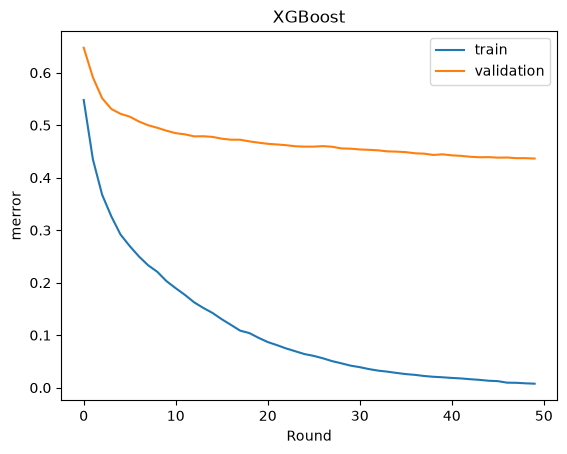

In [183]:
plot_evals_result("XGBoost", xgb_evals_result, "merror")

In [ ]:
# lightgbm
lgb_params = {
    "objective": "multiclass",
    "num_class": int(num_classes),
    "metric": "multi_error",
    "num_leaves": 31,
    "max_depth": -1,
    "learning_rate": 0.05,
    "random_state": 42,
    "verbosity": -1,
    "num_boost_round": 1000,
    "early_stopping_rounds": 50,
}

_p = {
    k: v
    for k, v in lgb_params.items()
    if k not in ("num_boost_round", "early_stopping_rounds")
}

dtrain = lgb.Dataset(X_TR, label=Y_TR, params=_p)
dvalid = lgb.Dataset(X_VA, label=Y_VA, params=_p)

lgb_evals_result = {}
lgb_bst = lgb.train(
    _p,
    dtrain,
    num_boost_round=lgb_params["num_boost_round"],
    valid_sets=[dtrain, dvalid],
    valid_names=["tr", "va"],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=lgb_params["early_stopping_rounds"], verbose=False
        ),
        lgb.record_evaluation(lgb_evals_result),
        lgb.log_evaluation(0),
    ],
)

for v in lgb_evals_result.values():
    v["merror"] = v.pop("multi_error")

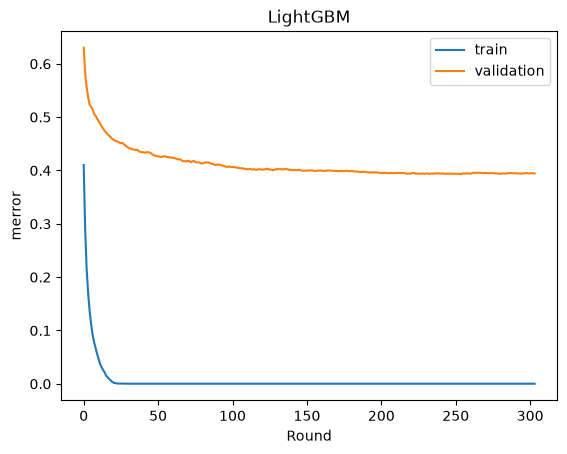

In [164]:
plot_evals_result("LightGBM", lgb_evals_result, "merror")

In [188]:
# catboost
tr_pool = ctb.Pool(X_TR, Y_TR)
va_pool = ctb.Pool(X_VA, Y_VA)

ctb_params = {
    "iterations": 1000,
    "learning_rate": 0.1,
    "loss_function": "MultiClass",
    "classes_count": int(num_classes),
    "eval_metric": "Accuracy",
    "depth": 6,
    "early_stopping_rounds": 50,
    "random_state": 42,
    "task_type": "GPU" if device == "cuda" else "CPU",
    "verbose": 0,
}

ctb_model = ctb.CatBoostClassifier(**ctb_params)

ctb_model.fit(tr_pool, eval_set=va_pool)

ctb_evals_result = ctb_model.get_evals_result()
ctb_evals_result = {
    "tr": {"merror": [1 - acc for acc in ctb_evals_result["learn"]["Accuracy"]]},
    "va": {"merror": [1 - acc for acc in ctb_evals_result["validation"]["Accuracy"]]},
}

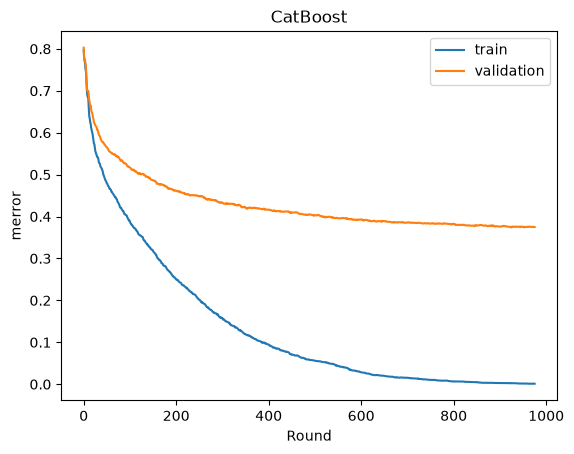

In [189]:
plot_evals_result("CatBoost", ctb_evals_result, "merror")

In [191]:
# sklearn decision tree
# we plot depth -> error

tree_params = {"depths": list(range(1, 65)), "random_state": 42}

tree_eval_results = defaultdict(lambda: defaultdict(lambda: pd.Series()))
for depth in tree_params["depths"]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=tree_params["random_state"])
    tree.fit(X_TR, Y_TR)
    tree_eval_results["tr"]["merror"][depth] = (tree.predict(X_TR) != Y_TR).mean()
    tree_eval_results["va"]["merror"][depth] = (tree.predict(X_VA) != Y_VA).mean()

for k in tree_eval_results:
    tree_eval_results[k]["merror"] = pd.Series(tree_eval_results[k]["merror"])

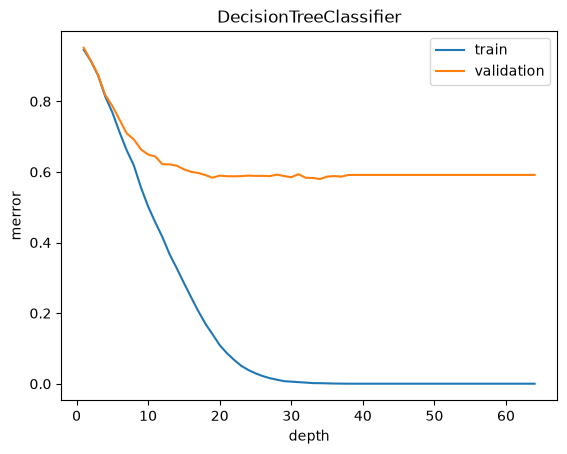

In [192]:
plot_evals_result("DecisionTreeClassifier", tree_eval_results, "merror", "depth")

In [ ]:
# write results to disk
def get_current_git_hash(short: bool = True) -> str | None:
    try:
        command = ["git", "rev-parse", "HEAD"]
        if short:
            command.insert(2, "--short")

        # Execute command and decode bytes to a string
        commit_hash = subprocess.check_output(command, stderr=subprocess.DEVNULL)
        return commit_hash.decode("utf-8").strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None


def _json_default(o):
    if isinstance(o, np.generic):
        return o.item()
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)


def _curve(values):
    s = pd.Series(values)
    return {"x": s.index.tolist(), "y": s.tolist()}


def write_results(path: str, models: dict[str, tuple], **info):
    """write model params + eval curves to a single json

    path   : file to write, e.g. "../results/Pedestrian.json"
    models : {name: (params, evals_result, x_name)}
    info   : any run level info to record alongside (dataset, device, split, ...)
    """
    info["models"] = {
        name: {
            "x_name": x_name,
            "params": params,
            "results": {
                split: {metric: _curve(values) for metric, values in metrics.items()}
                for split, metrics in evals.items()
            },
        }
        for name, (params, evals, x_name) in models.items()
    }

    path_ = Path(path)
    path_.parent.mkdir(parents=True, exist_ok=True)
    path_.write_text(json.dumps(info, indent=2, default=_json_default))

    return path_

In [1]:
_ = write_results(
    f"../results/{dataset}-{get_current_git_hash()}.json",
    {
        # "hashboost": (hb_params, hb_evals_result, "batch"),
        "xgboost": (xgb_params, xgb_evals_result, "round"),
        "lightgbm": (lgb_params, lgb_evals_result, "round"),
        "catboost": (ctb_params, ctb_evals_result, "round"),
        "tree": (tree_params, tree_eval_results, "depth"),
    },
    dataset=dataset,
    device=device,
    split={
        "fold": 0,
        "seed": 42,
        "n_tr": n_tr,
        "n_va": n_va,
        "n_te": n_te,
        "n_subsample": _size,
        "batch_size": data.batch_size,
        "num_classes": num_classes,
    },
)

NameError: name 'write_results' is not defined